In [88]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split  # To split data
from sklearn.preprocessing import StandardScaler, LabelEncoder  # To prepare data
from sklearn.linear_model import LogisticRegression    # Model 1
from sklearn.ensemble import RandomForestClassifier    # Model 2
from sklearn.svm import SVC                            # Model 3
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

In [89]:
df = pd.read_csv("heart_disease_uci.csv")

In [90]:
df.head(10)
print(f"Dataset Shape: {df.shape}")
print(f"Number of patients: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

Dataset Shape: (920, 16)
Number of patients: 920
Number of features: 16


In [91]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [92]:
missing_values = df.isnull().sum()

# Show only columns with missing values
missing_columns = missing_values[missing_values > 0]

print("Columns with Missing Values:")
print(missing_columns)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Columns with Missing Values:
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64

Total missing values: 1759


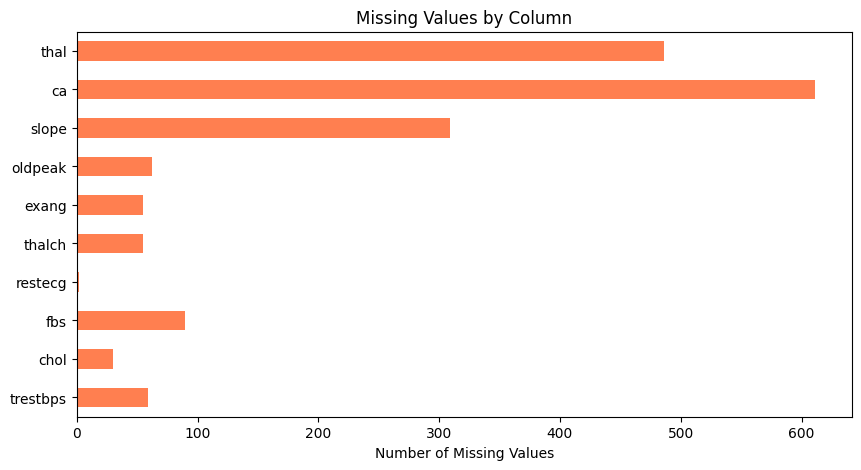

In [93]:
if len(missing_columns) > 0:
    plt.figure(figsize=(10, 5))
    missing_columns.plot(kind='barh', color='coral')
    plt.title('Missing Values by Column')
    plt.xlabel('Number of Missing Values')
    plt.show()

In [94]:
df.drop(columns=['ca'], inplace=True)
df.drop(columns=['thal'], inplace=True)

In [95]:
df['trestbps'].fillna(df['trestbps'].median(), inplace = True)
df['chol'].fillna(df['chol'].median(), inplace=True)
df['fbs'].fillna(df['fbs'].mode()[0], inplace=True)
df['thalch'].fillna(df['thalch'].median(), inplace=True)
df['exang'].fillna(df['exang'].mode()[0], inplace=True)
df['oldpeak'].fillna(df['oldpeak'].median(), inplace=True)

C:\Users\abhin\AppData\Local\Temp\ipykernel_22812\386306359.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['trestbps'].fillna(df['trestbps'].median(), inplace = True)
C:\Users\abhin\AppData\Local\Temp\ipykernel_22812\386306359.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

In [96]:
df.drop(columns=['slope'], inplace= True)
df.drop(columns=['id'], inplace=True)
df.drop(columns=['dataset'], inplace=True)

In [97]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     2
thalch      0
exang       0
oldpeak     0
num         0
dtype: int64

In [98]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   cp        920 non-null    object 
 3   trestbps  920 non-null    float64
 4   chol      920 non-null    float64
 5   fbs       920 non-null    bool   
 6   restecg   918 non-null    object 
 7   thalch    920 non-null    float64
 8   exang     920 non-null    bool   
 9   oldpeak   920 non-null    float64
 10  num       920 non-null    int64  
dtypes: bool(2), float64(4), int64(2), object(3)
memory usage: 66.6+ KB


,age,trestbps,chol,thalch,oldpeak,num
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,53.510870,131.995652,199.908696,137.692391,0.853261,0.995652
std,9.424685,18.451300,109.040171,25.145235,1.058049,1.142693
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,177.750000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,1.000000
75%,60.000000,140.000000,267.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [99]:
# Created a new column 'target' where:
# - 0 means no heart disease (when num == 0)
# - 1 means has heart disease (when num > 0)

df['target'] = (df['num'] > 0).astype(int)

# Show the distribution
print("Target Variable Distribution:")
print(df['target'].value_counts())
print("\n0 = No Heart Disease, 1 = Has Heart Disease")

Target Variable Distribution:
target
1    509
0    411
Name: count, dtype: int64

0 = No Heart Disease, 1 = Has Heart Disease


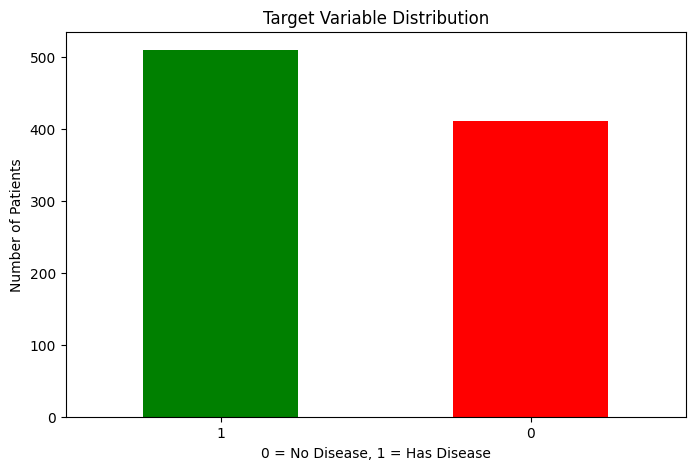

No Disease: 411 patients (44.7%)
Has Disease: 509 patients (55.3%)


In [100]:

plt.figure(figsize=(8, 5))


colors = ['green', 'red']
df['target'].value_counts().plot(kind='bar', color=colors)
plt.title('Target Variable Distribution')
plt.xlabel('0 = No Disease, 1 = Has Disease')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.show()


no_disease = (df['target'] == 0).sum()
has_disease = (df['target'] == 1).sum()
total = len(df)

print(f"No Disease: {no_disease} patients ({no_disease/total*100:.1f}%)")
print(f"Has Disease: {has_disease} patients ({has_disease/total*100:.1f}%)")

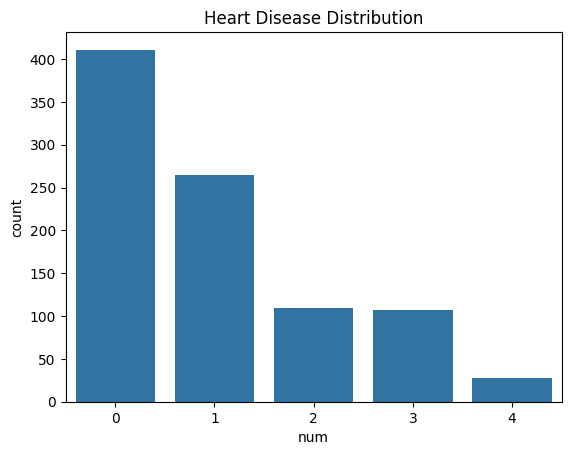

In [101]:
sns.countplot(x='num', data=df)
plt.title("Heart Disease Distribution")
plt.show()

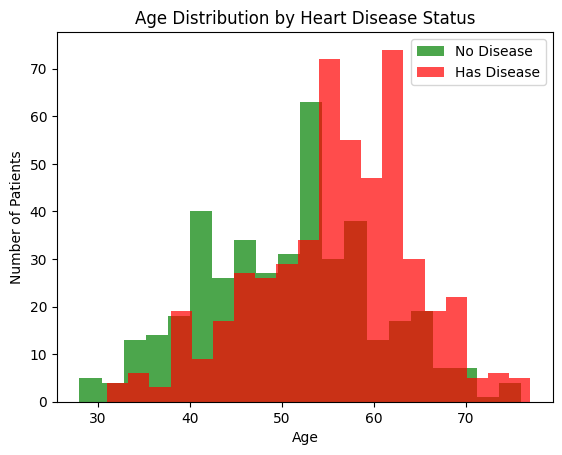

Observation: Older patients tend to have more heart disease.


In [102]:
plt.hist(df[df['target']==0]['age'], bins=20, alpha=0.7, label='No Disease', color='green')
plt.hist(df[df['target']==1]['age'], bins=20, alpha=0.7, label='Has Disease', color='red')

plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.title('Age Distribution by Heart Disease Status')
plt.legend()
plt.show()

print("Observation: Older patients tend to have more heart disease.")

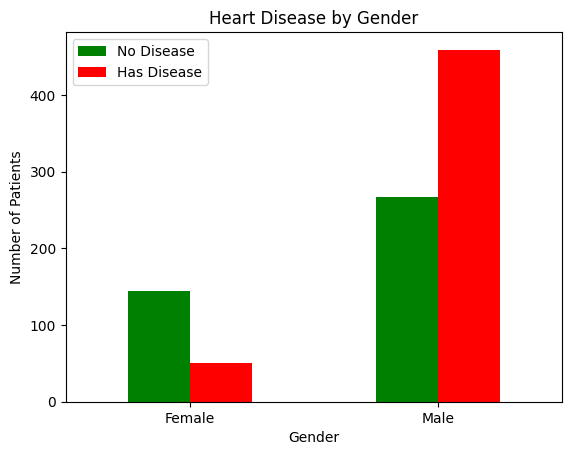

target    0    1
sex             
Female  144   50
Male    267  459


In [103]:
gender_disease = pd.crosstab(df['sex'], df['target'])
gender_disease.plot(kind='bar', color=['green', 'red'])

plt.title('Heart Disease by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.legend(['No Disease', 'Has Disease'])
plt.xticks(rotation=0)
plt.show()

print(gender_disease)

In [104]:
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (920, 14)
Target (y) shape: (920,)
